In [ ]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import math

data = pd.read_csv('exoTrain.csv')

X = data.drop('LABEL', axis=1).values
y = data['LABEL'].values - 1  # make labels 0,1

X = X[:, :500] 
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# convert AFTER split
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)

# reshape for LSTM
X_train = X_train.unsqueeze(-1)
X_val   = X_val.unsqueeze(-1)


train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0) #for gpu

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(1, 64)

        self.pos_encoder = PositionalEncoding(64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.embedding(x)

        x = self.pos_encoder(x)

        x = self.transformer(x)

        x = x.mean(dim=1)   # global pooling - instead of last timestamp this uses whole sequence 

        x = self.fc(x)

        return x

model = TransformerModel()


class_counts = torch.bincount(y_train)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:
        outputs = model(xb)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds)
        all_labels.append(yb)

# combine batches
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

print("Total evaluated samples:", len(all_preds))

accuracy = (all_preds == all_labels).float().mean()
print("Validation Accuracy:", accuracy.item())

print(confusion_matrix(all_labels.numpy(), all_preds.numpy()))
print(classification_report(all_labels.numpy(), all_preds.numpy()))  ##using only 500 sequence length instead of 3000 and reduced bathc size form 32 to 16

Epoch 1, Train Loss: 175.8719
Epoch 2, Train Loss: 174.9735
Epoch 3, Train Loss: 176.0587
Epoch 4, Train Loss: 176.4640
Epoch 5, Train Loss: 176.6775
Epoch 6, Train Loss: 176.7109
Epoch 7, Train Loss: 176.7472
Epoch 8, Train Loss: 176.6829
Epoch 9, Train Loss: 176.7293
Epoch 10, Train Loss: 176.6543
Epoch 11, Train Loss: 176.7563
Epoch 12, Train Loss: 176.7485
Epoch 13, Train Loss: 176.7487
Epoch 14, Train Loss: 176.6764
Epoch 15, Train Loss: 176.5524
Epoch 16, Train Loss: 176.4974
Epoch 17, Train Loss: 176.7623
Epoch 18, Train Loss: 176.7537
Epoch 19, Train Loss: 176.7073
Epoch 20, Train Loss: 176.7710
Total evaluated samples: 1018
Validation Accuracy: 0.0068762279115617275
[[   0 1011]
 [   0    7]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1011
           1       0.01      1.00      0.01         7

    accuracy                           0.01      1018
   macro avg       0.00      0.50      0.01      1018
weighted avg     

e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

In [ ]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import math

data = pd.read_csv('exoTrain.csv')

X = data.drop('LABEL', axis=1).values
y = data['LABEL'].values - 1  # make labels 0,1

X = X[:, :300] 
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# convert AFTER split
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)

# reshape for LSTM
X_train = X_train.unsqueeze(-1)
X_val   = X_val.unsqueeze(-1)


train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0) #for gpu

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(1, 64)

        self.pos_encoder = PositionalEncoding(64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.embedding(x)

        x = self.pos_encoder(x)

        x = self.transformer(x)

        x = x.mean(dim=1)   # global pooling - instead of last timestamp this uses whole sequence 

        x = self.fc(x)

        return x

model = TransformerModel()

class_counts = torch.bincount(y_train)
weights = 1.0 / class_counts.float()
weights = weights/weights.sum()

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:
        outputs = model(xb)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds)
        all_labels.append(yb)

# combine batches
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

print("Total evaluated samples:", len(all_preds))

accuracy = (all_preds == all_labels).float().mean()
print("Validation Accuracy:", accuracy.item())

print(confusion_matrix(all_labels.numpy(), all_preds.numpy()))
print(classification_report(all_labels.numpy(), all_preds.numpy()))  ##removed sampler + reduced sequence from 500 to 300

Epoch 1, Train Loss: 15.5148
Epoch 2, Train Loss: 12.3889
Epoch 3, Train Loss: 11.8015
Epoch 4, Train Loss: 12.0314
Epoch 5, Train Loss: 12.0734
Epoch 6, Train Loss: 13.1465
Epoch 7, Train Loss: 12.2565
Epoch 8, Train Loss: 12.1039
Epoch 9, Train Loss: 12.0473
Epoch 10, Train Loss: 12.5712
Epoch 11, Train Loss: 11.8327
Epoch 12, Train Loss: 12.4120
Epoch 13, Train Loss: 12.3713
Epoch 14, Train Loss: 12.6911
Epoch 15, Train Loss: 11.9993
Epoch 16, Train Loss: 11.3693
Epoch 17, Train Loss: 12.2360
Epoch 18, Train Loss: 12.1668
Epoch 19, Train Loss: 11.7444
Epoch 20, Train Loss: 11.9682
Total evaluated samples: 1018
Validation Accuracy: 0.9931237697601318
[[1011    0]
 [   7    0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.99      0.99      0

e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

Epoch 1, Train Loss: 13.8852
Epoch 2, Train Loss: 12.4341
Epoch 3, Train Loss: 12.3050
Epoch 4, Train Loss: 12.5082
Epoch 5, Train Loss: 11.4547
Epoch 6, Train Loss: 11.7402
Epoch 7, Train Loss: 12.6111
Epoch 8, Train Loss: 12.9955
Epoch 9, Train Loss: 12.3706
Epoch 10, Train Loss: 11.8874
Epoch 11, Train Loss: 12.3215
Epoch 12, Train Loss: 11.6592
Epoch 13, Train Loss: 11.8001
Epoch 14, Train Loss: 11.8319
Epoch 15, Train Loss: 11.8564
Epoch 16, Train Loss: 12.2183
Epoch 17, Train Loss: 11.7342
Epoch 18, Train Loss: 12.0482
Epoch 19, Train Loss: 12.5197
Epoch 20, Train Loss: 11.4651

VALIDATION RESULTS
Accuracy: 0.9931237697601318

Confusion Matrix
[[1011    0]
 [   7    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0

e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

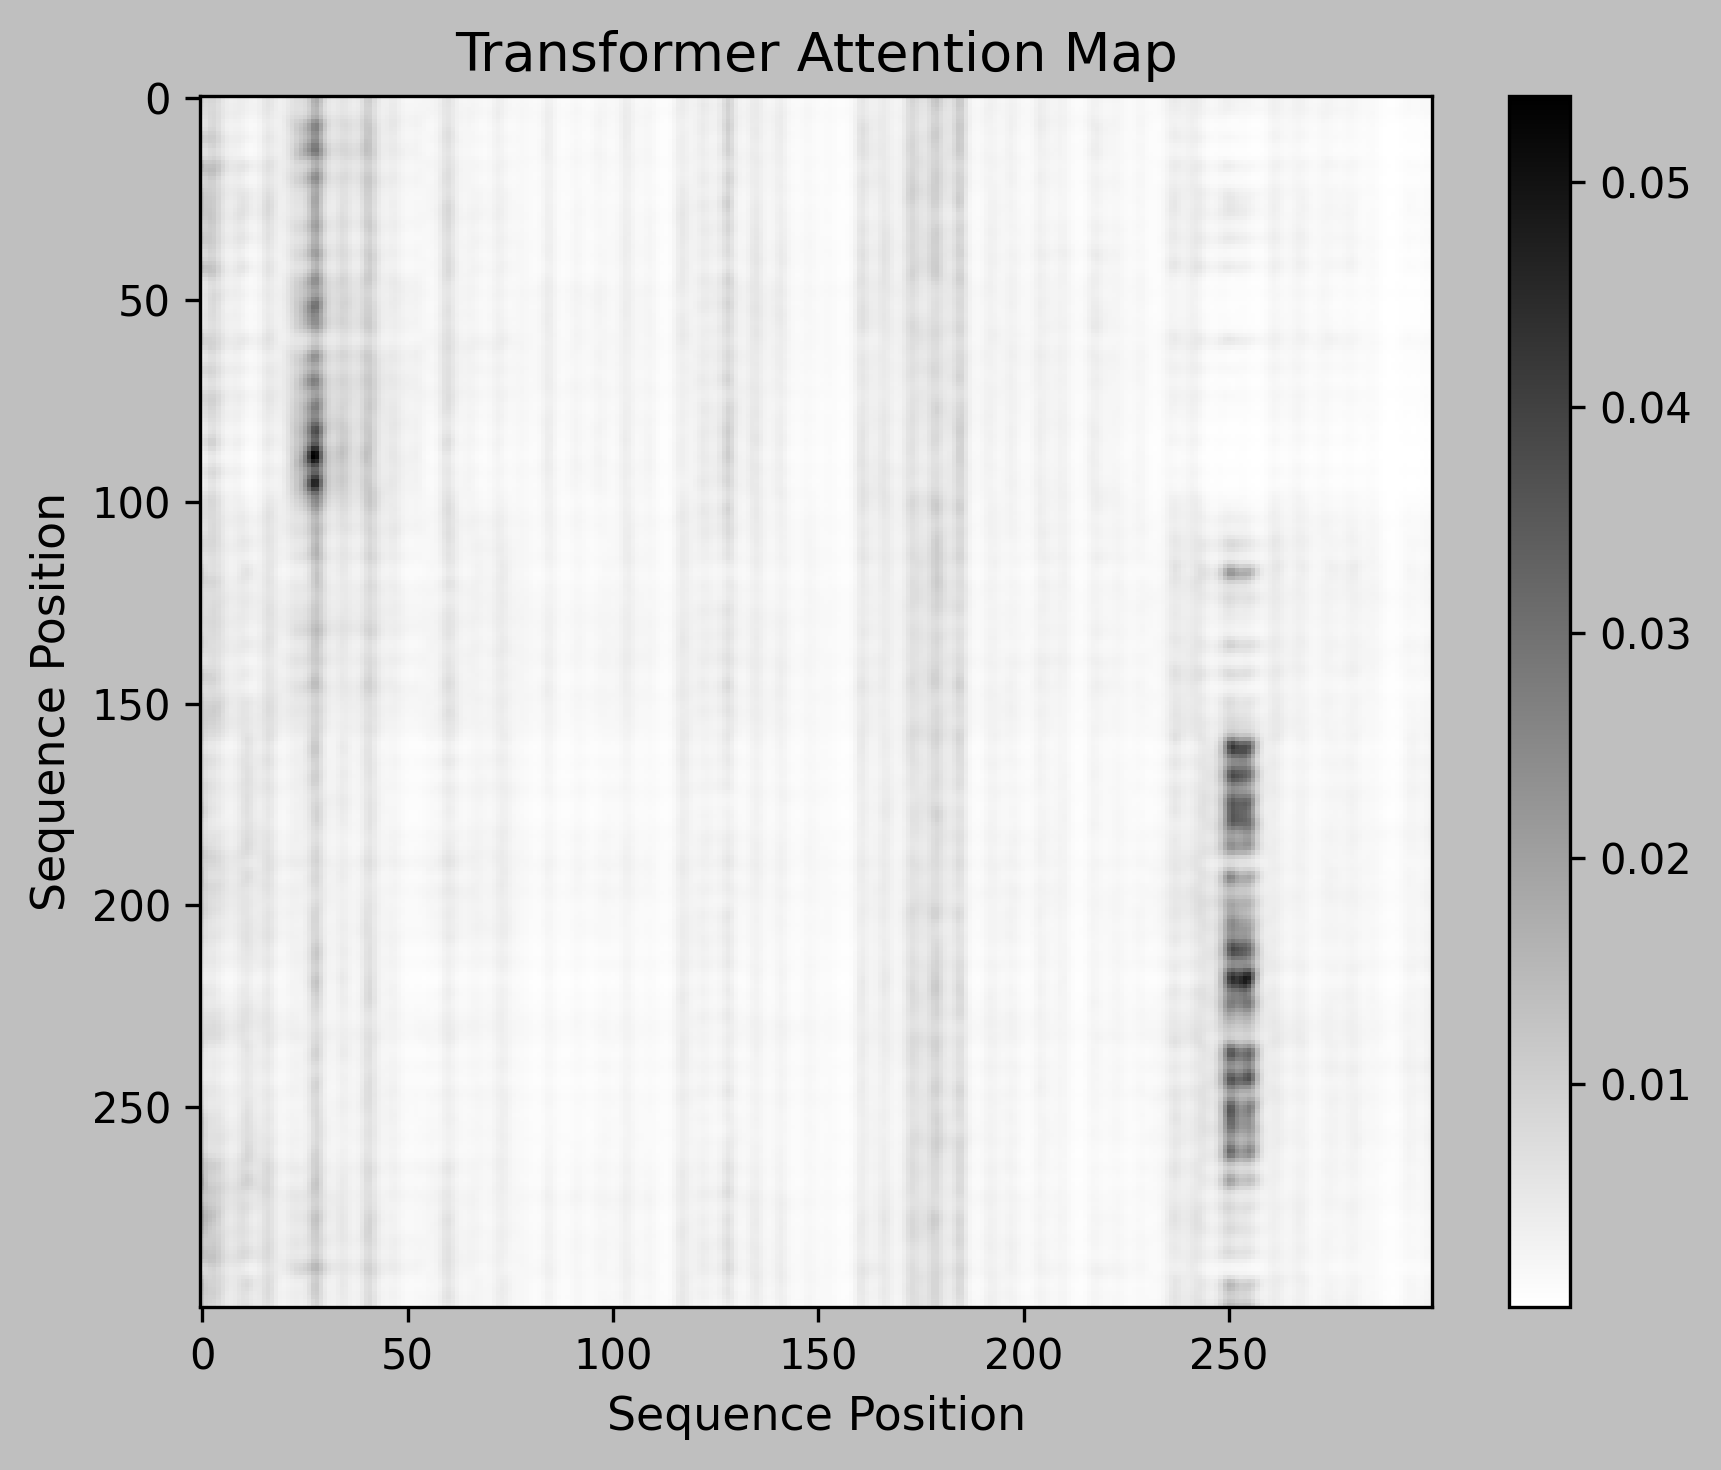


Attention map saved as:
transformer_attention_map.png


In [ ]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math


data = pd.read_csv('exoTrain.csv')

X = data.drop('LABEL', axis=1).values
y = data['LABEL'].values - 1   # convert labels to 0,1

# reduce sequence length
X = X[:, :300]

# train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

# reshape for transformer
# (batch, sequence_length, features)

X_train = X_train.unsqueeze(-1)
X_val = X_val.unsqueeze(-1)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)



class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)



class CustomTransformerLayer(nn.Module):
    def __init__(self, d_model=64, nhead=2):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Linear(128, d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)

        self.attention_weights = None

    def forward(self, x):

        attn_output, attn_weights = self.attention(
            x,
            x,
            x,
            need_weights=True,
            average_attn_weights=False
        )

        # shape:
        # (batch, heads, seq, seq)

        self.attention_weights = attn_weights

        x = self.norm1(x + attn_output)

        ff_output = self.ff(x)

        x = self.norm2(x + ff_output)

        return x


class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(1, 64)

        self.pos_encoder = PositionalEncoding(64)

        # custom transformer layer
        self.transformer_layer = CustomTransformerLayer(
            d_model=64,
            nhead=2
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):

        # embedding
        x = self.embedding(x)

        # positional encoding
        x = self.pos_encoder(x)

        # custom transformer
        x = self.transformer_layer(x)

        # global average pooling
        x = x.mean(dim=1)

        # classifier
        x = self.fc(x)

        return x



model = TransformerModel()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


epochs = 20

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for xb, yb in train_loader:

        outputs = model(xb)

        loss = criterion(outputs, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")


model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for xb, yb in val_loader:

        outputs = model(xb)

        _, preds = torch.max(outputs, 1)

        all_preds.append(preds)

        all_labels.append(yb)

# combine batches
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# accuracy
accuracy = (all_preds == all_labels).float().mean()

print("\nVALIDATION RESULTS")
print("Accuracy:", accuracy.item())

print("\nConfusion Matrix")
print(confusion_matrix(
    all_labels.numpy(),
    all_preds.numpy()
))

print("\nClassification Report")
print(classification_report(
    all_labels.numpy(),
    all_preds.numpy()
))


model.eval()

# choose one validation sample
sample = X_val[0].unsqueeze(0)

with torch.no_grad():
    _ = model(sample)

# attention weights
attention = model.transformer_layer.attention_weights

# shape:
# (batch, heads, seq, seq)

# remove batch dimension
attention = attention.squeeze(0)

# average across heads
attention = attention.mean(dim=0)

# convert to numpy
attention = attention.cpu().numpy()


plt.style.use('grayscale')

plt.figure(figsize=(6, 5), dpi=300)

plt.imshow(
    attention,
    cmap='gray_r',
    aspect='auto'
)

plt.xlabel('Sequence Position', fontsize=11)
plt.ylabel('Sequence Position', fontsize=11)
plt.title('Transformer Attention Map', fontsize=13)

plt.colorbar()

plt.tight_layout()

plt.savefig(
    'transformer_attention_map.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nAttention map saved as:")
print("transformer_attention_map.png")

Epoch 1, Train Loss: 17.9484
Epoch 2, Train Loss: 11.9118
Epoch 3, Train Loss: 11.9796
Epoch 4, Train Loss: 12.3107
Epoch 5, Train Loss: 12.2256
Epoch 6, Train Loss: 12.0124
Epoch 7, Train Loss: 11.6371
Epoch 8, Train Loss: 11.9095
Epoch 9, Train Loss: 12.0807
Epoch 10, Train Loss: 11.7774
Epoch 11, Train Loss: 12.2069
Epoch 12, Train Loss: 11.8891
Epoch 13, Train Loss: 12.0904
Epoch 14, Train Loss: 11.6376
Epoch 15, Train Loss: 11.4047
Epoch 16, Train Loss: 11.4009
Epoch 17, Train Loss: 11.9610
Epoch 18, Train Loss: 11.4788
Epoch 19, Train Loss: 11.5835
Epoch 20, Train Loss: 11.8075

VALIDATION RESULTS
Accuracy: 0.9931237697601318

Confusion Matrix
[[1011    0]
 [   7    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0

e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Programming_vsc\exoplanets\detecting exoplanets raw photometric\dlenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

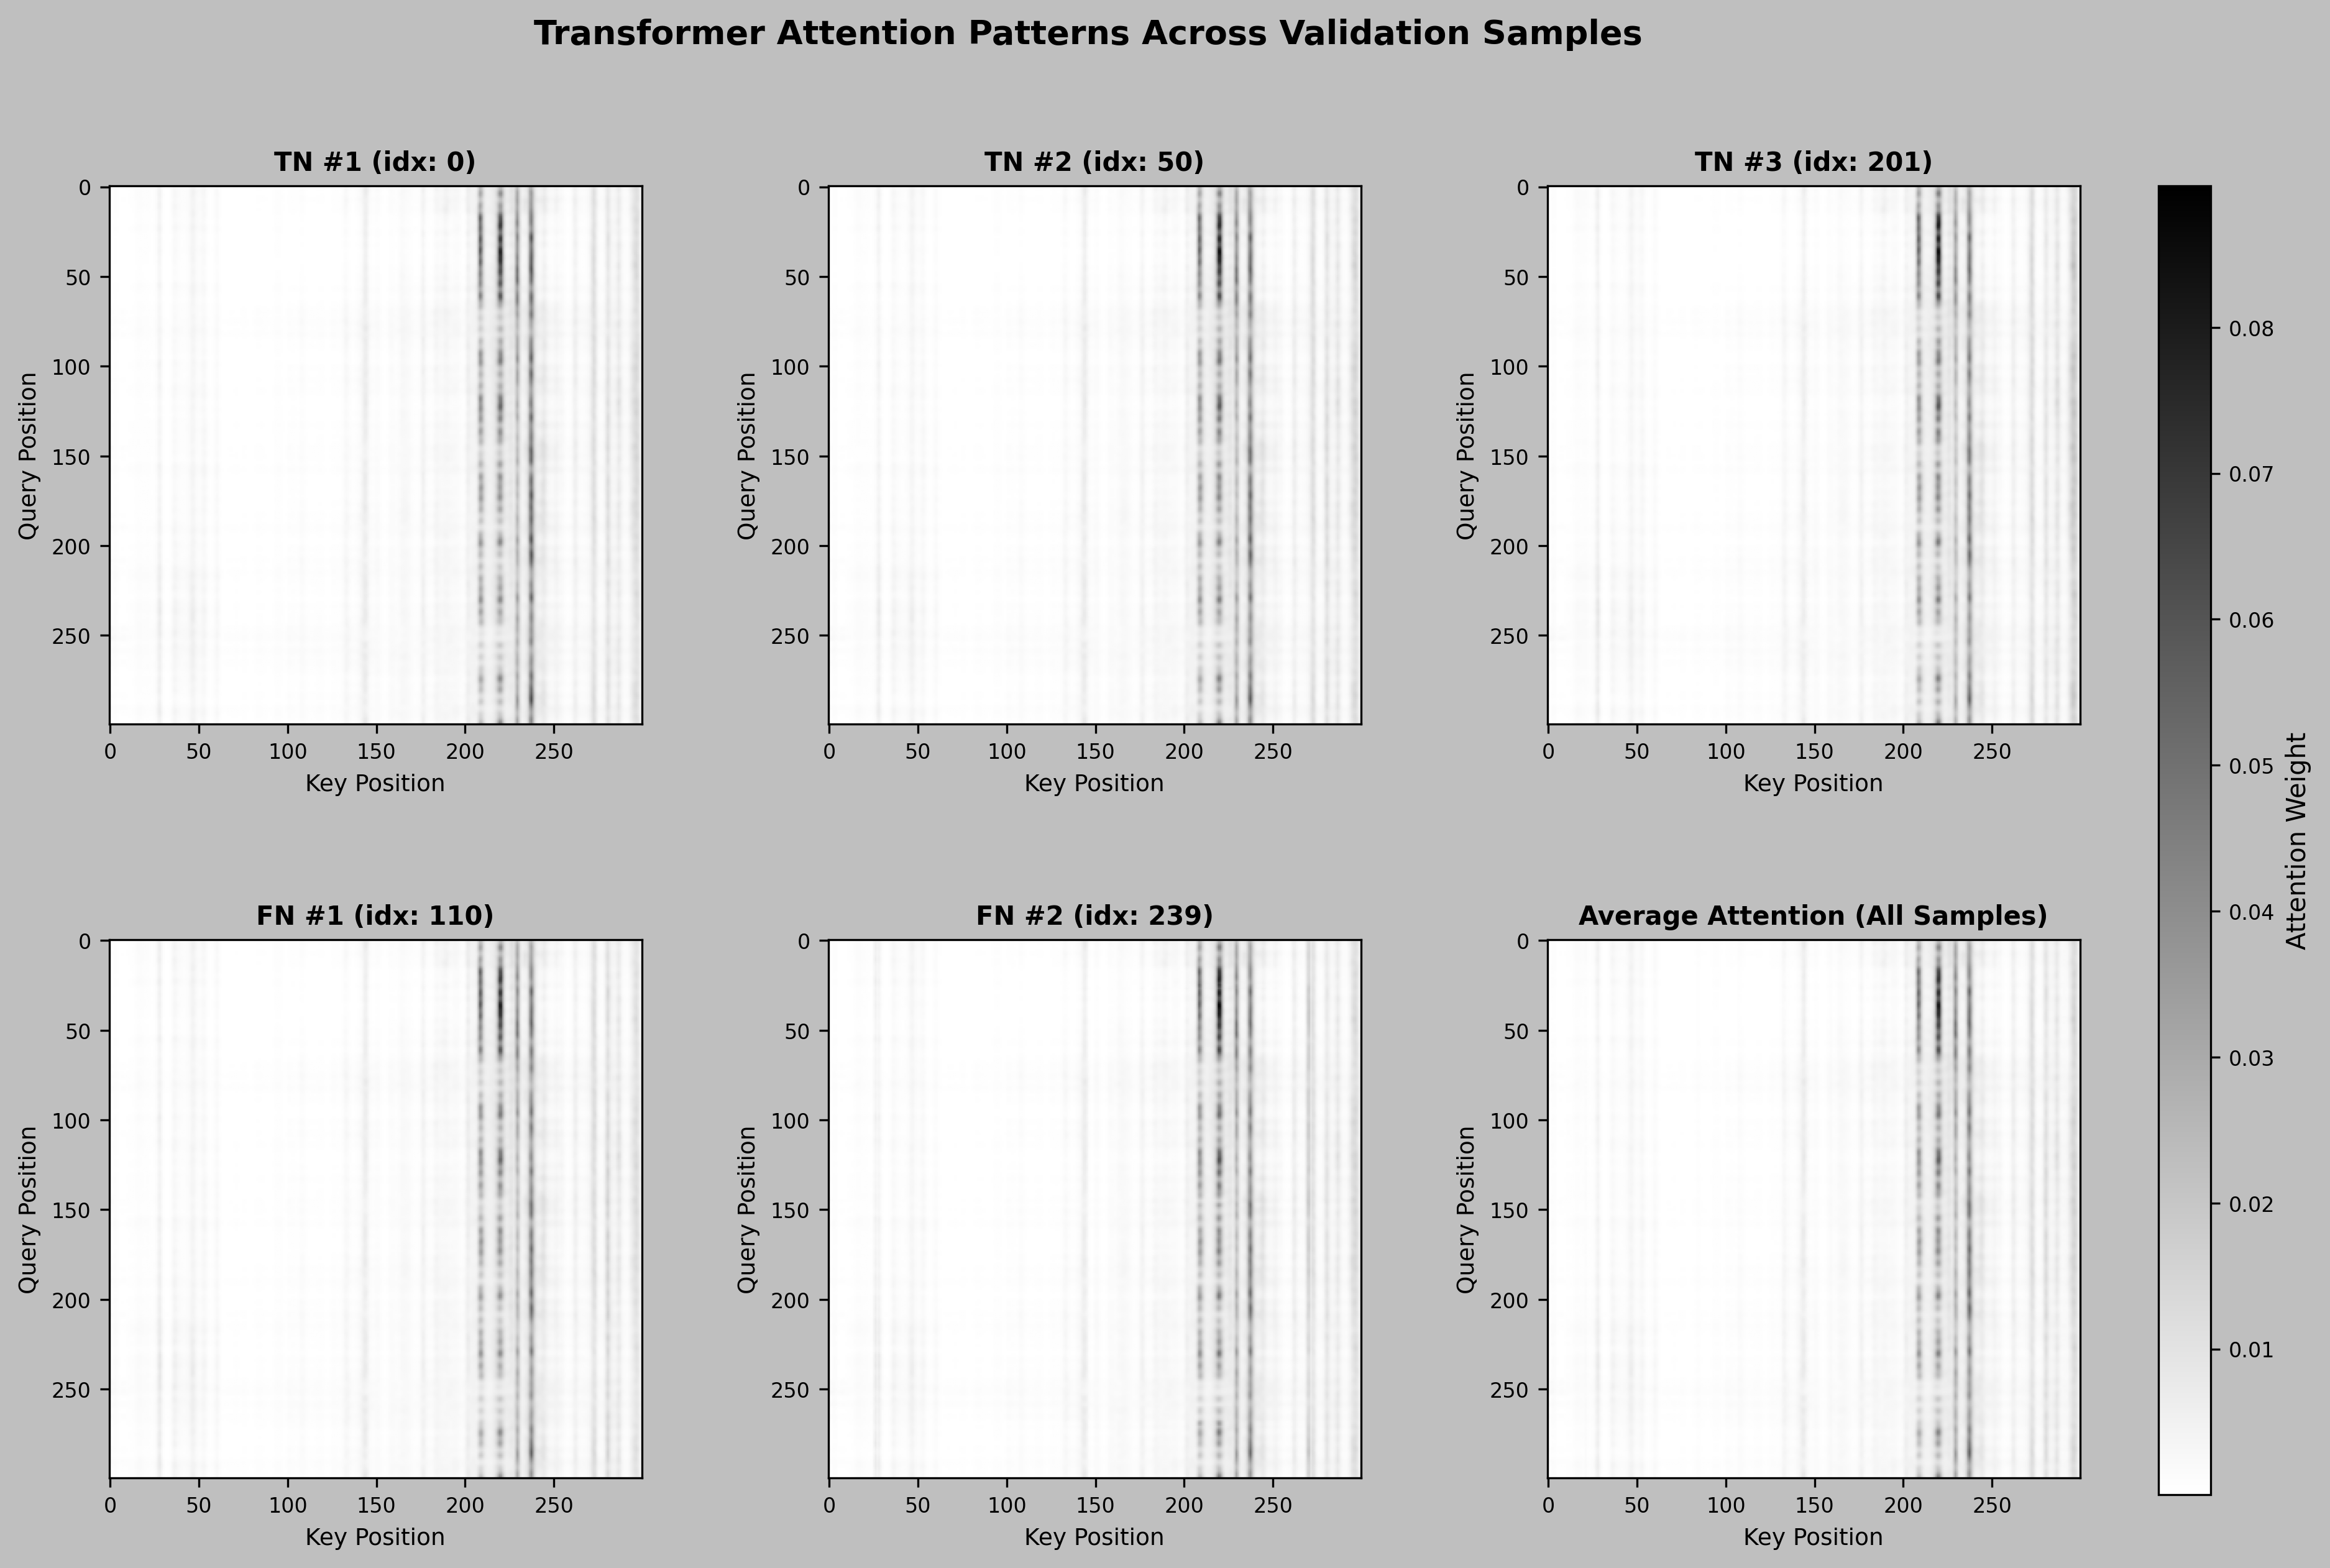

Saved: transformer_attention_grid.png


In [6]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

data = pd.read_csv('exoTrain.csv')

X = data.drop('LABEL', axis=1).values
y = data['LABEL'].values - 1   # convert labels to 0,1

# reduce sequence length
X = X[:, :300]

# train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

# reshape for transformer
# (batch, sequence_length, features)

X_train = X_train.unsqueeze(-1)
X_val = X_val.unsqueeze(-1)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)



class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)



class CustomTransformerLayer(nn.Module):
    def __init__(self, d_model=64, nhead=2):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Linear(128, d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)

        self.attention_weights = None

    def forward(self, x):

        attn_output, attn_weights = self.attention(
            x,
            x,
            x,
            need_weights=True,
            average_attn_weights=False
        )

        # shape:
        # (batch, heads, seq, seq)

        self.attention_weights = attn_weights

        x = self.norm1(x + attn_output)

        ff_output = self.ff(x)

        x = self.norm2(x + ff_output)

        return x


class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(1, 64)

        self.pos_encoder = PositionalEncoding(64)

        # custom transformer layer
        self.transformer_layer = CustomTransformerLayer(
            d_model=64,
            nhead=2
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):

        # embedding
        x = self.embedding(x)

        # positional encoding
        x = self.pos_encoder(x)

        # custom transformer
        x = self.transformer_layer(x)

        # global average pooling
        x = x.mean(dim=1)

        # classifier
        x = self.fc(x)

        return x



model = TransformerModel()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


epochs = 20

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for xb, yb in train_loader:

        outputs = model(xb)

        loss = criterion(outputs, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")


model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for xb, yb in val_loader:

        outputs = model(xb)

        _, preds = torch.max(outputs, 1)

        all_preds.append(preds)

        all_labels.append(yb)

# combine batches
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)


# accuracy
accuracy = (all_preds == all_labels).float().mean()

print("\nVALIDATION RESULTS")
print("Accuracy:", accuracy.item())

print("\nConfusion Matrix")
print(confusion_matrix(
    all_labels.numpy(),
    all_preds.numpy()
))

print("\nClassification Report")
print(classification_report(
    all_labels.numpy(),
    all_preds.numpy()
))

# FIND TN AND FN SAMPLES
tn_indices = []
fn_indices = []
for i in range(len(all_labels)):
    true = all_labels[i].item()
    pred = all_preds[i].item()
    if true == 0 and pred == 0:
        tn_indices.append(i)
    elif true == 1 and pred == 0:
        fn_indices.append(i)
print("\nTN count:", len(tn_indices))
print("FN count:", len(fn_indices))
print("First TNs:", tn_indices[:10])
print("First FNs:", fn_indices[:10])

# ATTENTION EXTRACTION FUNCTION
def get_attention_map(sample_idx):
    model.eval()
    sample = X_val[sample_idx].unsqueeze(0)
    with torch.no_grad():
        _ = model(sample)
    attention = model.transformer_layer.attention_weights
    attention = attention.squeeze(0)
    attention = attention.mean(dim=0)
    return attention.cpu().numpy()

# SELECT SAMPLES
tn1 = tn_indices[0]
tn2 = tn_indices[50]
tn3 = tn_indices[200]
fn1 = fn_indices[0]
fn2 = fn_indices[1] if len(fn_indices) > 1 else fn_indices[0]

# COMPUTE AVERAGE ATTENTION MAP
all_attention_maps = []
print("\nComputing average attention map...")
for idx in range(len(X_val)):
    attn = get_attention_map(idx)
    all_attention_maps.append(attn)
average_attention = np.mean(np.stack(all_attention_maps), axis=0)

# GENERATE 2x3 PAPER FIGURE — matching reference image exactly
plt.style.use("grayscale")

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 9),
    dpi=300
)

maps = [
    get_attention_map(tn1),
    get_attention_map(tn2),
    get_attention_map(tn3),
    get_attention_map(fn1),
    get_attention_map(fn2),
    average_attention
]

titles = [
    f"TN #1 (idx: {tn1})",
    f"TN #2 (idx: {tn2})",
    f"TN #3 (idx: {tn3})",
    f"FN #1 (idx: {fn1})",
    f"FN #2 (idx: {fn2})",
    "Average Attention (All Samples)"
]

vmin = min(m.min() for m in maps)
vmax = max(m.max() for m in maps)

im = None
for ax, attn, title in zip(axes.flatten(), maps, titles):
    im = ax.imshow(
        attn,
        cmap="gray_r",
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Key Position", fontsize=9)
    ax.set_ylabel("Query Position", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)

# Reserve space on right, then place colorbar in its own axes
fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.78])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Attention Weight", fontsize=10)
cbar.ax.tick_params(labelsize=8)

plt.suptitle(
    "Transformer Attention Patterns Across Validation Samples",
    fontsize=13,
    fontweight="bold"
)

plt.savefig(
    "transformer_attention_grid.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Saved: transformer_attention_grid.png")


